## Exercise 1

Read in a bunch of tweets that were collected during the airing of the 'Red Wedding' episode of Game of Thrones from the file `got_tweets.csv`.

Parse all the hashtags out of the texts, then count their overall occurrences. What are the 10 most common hashtags? Make a bar chart of these top 10 hashtags! Create a plot of hashtag timelines for the most interesting and frequent hashtags!

In [1]:
from dotenv import load_dotenv
import os
import pandas as pd
import string
import numpy as np
import matplotlib.pyplot as plt
load_dotenv("../env_variables")

DATASET_DIR = os.getenv("DATASET_DIR")
DATASET_DIR="/v/courses/2025-202425adatexplorcisvizualizci.public/Datasets/NLP"

filename=f"{DATASET_DIR}/NLP/got_tweets.csv"

In [2]:
df = pd.read_csv(f'{DATASET_DIR}/got_tweets.csv')

In [3]:
text = df['text']
hashtags = []


for tw in text:
    words = tw.split()
    tags_in_tweet = []
    
    for word in words:
        # Check if the word is a hashtag
        if word.startswith("#"):
            # Remove the '#' and convert the tag to lowercase
            tag = word[1:].lower()
            # Add the cleaned tag to the list
            tags_in_tweet.append(tag)
    
    # Add the list of hashtags for this tweet to the main list
    hashtags.append(tags_in_tweet)

flattened_hashtags = []

for sublist in hashtags:
    for hashtag in sublist:
        flattened_hashtags.append(hashtag)

# Replace the original hashtags list with the flattened version
hashtags = flattened_hashtags




In [4]:


cleaned_hashtags = []

for h in hashtags:
    cleaned = ''
    
    # Loop through each character in the hashtag
    for c in h:
        if c not in string.punctuation:
            cleaned += c
    
    cleaned_hashtags.append('#' + cleaned)

hashtags = cleaned_hashtags



In [5]:
hashtag_count = {}
for w in hashtags:
    if w in hashtag_count.keys():
        hashtag_count[w] += 1
    else:
        hashtag_count[w] = 1

In [6]:
hashtag_counts_df = pd.DataFrame({'words': list(hashtag_count.keys()),
                                  'counts': list(hashtag_count.values())}).sort_values(by=['counts'],
                                                                                       ascending=False,
                                                                                       ignore_index=True)

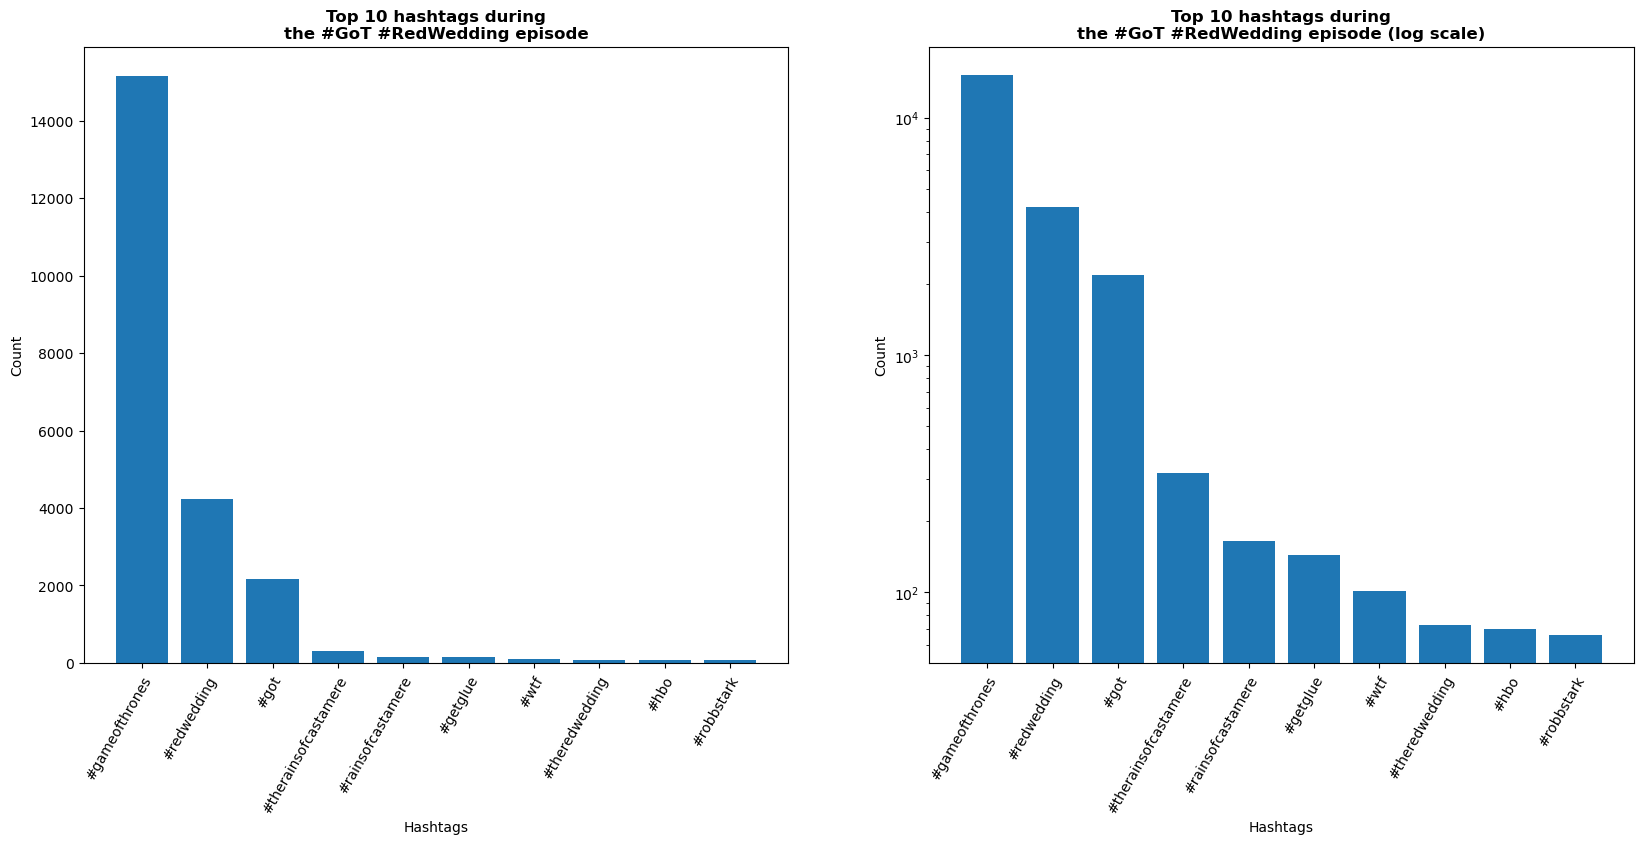

In [7]:
ncols = 2
nrows = 1
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*10, nrows*8))

# Number of hashtags plotted
n_hash = 10

# Choose colors for bars
start = 0.0
stop = 0.8
cm_subsection = np.linspace(start, stop, n_hash) 

axes[0].set_title('Top {0} hashtags during\nthe #GoT #RedWedding episode'.format(n_hash),
                  fontweight='bold')
axes[1].set_title('Top {0} hashtags during\nthe #GoT #RedWedding episode (log scale)'.format(n_hash),
                   fontweight='bold')


for i in range(ncols):
    ax = axes[i]
    ax.bar(x=hashtag_counts_df['words'][:n_hash],
           height=hashtag_counts_df['counts'][:n_hash],
           tick_label=hashtag_counts_df['words'][:n_hash]
          )
    ax.set_xlabel('Hashtags')
    ax.set_ylabel('Count')

    ax.set_xticklabels(hashtag_counts_df['words'][:n_hash],
                       rotation=60, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='both', which='major')

axes[1].set_yscale('log')

plt.show()

## Exercise 2

Tokenize the text of the tweets, and gather the 'real' words for each tweet.

By 'real' words, there should be:
* no punctuations
* hashtags only without `#` mark
* no user mentions
* no URLs
* no emojis
* no numbers

Count word occurrences, make a histogram of the occurrences. What are the top words? Are they what you expected?

What crazy words did you get? Explain possible approaches, with which you could throw out this kind of junk text as well.

In [8]:
text_flt = text.copy()

In [9]:
import re


def extract_real_words(tweet):
    words = tweet.split()
    real_words = []

    for word in words:
        # Remove URLs
        if re.match(r'http[s]?://', word):
            continue

        # Remove mentions
        if word.startswith('@'):
            continue

        # Remove emojis (non-word characters outside typical ranges)
        if re.search(r'[\U00010000-\U0010ffff]', word):
            continue

        # Remove numbers or words containing digits
        if any(char.isdigit() for char in word):
            continue

        # Remove punctuation
        word = word.strip(string.punctuation)

        # Skip if empty after cleaning
        if not word:
            continue

        # Remove hashtag symbol but keep the tag text
        if word.startswith('#'):
            word = word[1:]

        # Skip if it's still not alphabetic (e.g., a leftover symbol)
        if not word.isalpha():
            continue

        # Convert to lowercase and add to list
        real_words.append(word.lower())

    return real_words




In [10]:
from collections import Counter

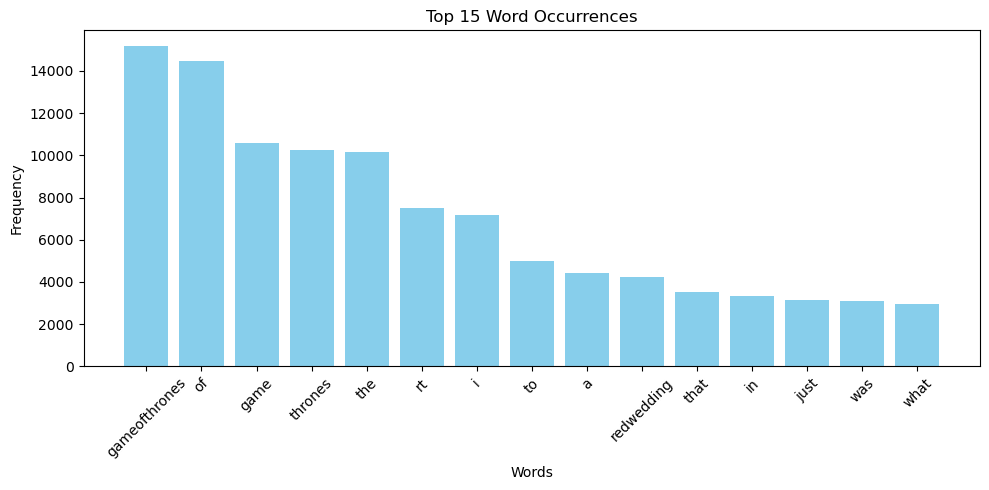

In [11]:
all_real_words = []
for tweet in text_flt:
    all_real_words.extend(extract_real_words(tweet))

# Count word frequencies
word_counts = Counter(all_real_words)

# Show raw counts (optional)
#print("Word Frequencies:")
#for word, count in word_counts.most_common():
#    print(f"{word}: {count}")

top_words = word_counts.most_common(15)

# Separate into labels and values
labels, values = zip(*top_words)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue')
plt.xticks(rotation=45)
plt.title("Top 15 Word Occurrences")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

I have no idea what "rt" means, and to throw out these junk words I would implement it only to count words that are at least 3 letters long, and has at least 1 vowel. 

## Exercise 3


Extract the stopword list for the English language with the help of `nltk`. Download the standard Brown Corpus also from `nltk`, count the relative frequency of stopwords in both the Brown Corpus and the GoT tweets. Make a scatterplot of your results, try to explain possible similarities and deviations. What is the correlation in the stopword frequencies of the two datasets?

In [12]:
import nltk
from nltk.corpus import stopwords, brown
from nltk import download
from scipy.stats import pearsonr

In [13]:
download('stopwords')
download('brown')

[nltk_data] Downloading package stopwords to /v/x38j5q/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package brown to /v/x38j5q/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

In [14]:
stop_words = set(stopwords.words('english'))
brown_words = [word.lower() for word in brown.words()]
brown_cleaned = [
    word for word in brown_words
    if word.isalpha() and word not in string.punctuation
]

In [15]:
brown_freq = Counter(brown_cleaned)
total_brown = sum(brown_freq.values())

brown_stopword_freq = {
    word: brown_freq[word] / total_brown for word in stop_words
}


In [16]:

total_tweet = sum(word_counts.values())

# Compute relative frequencies of stopwords in tweets
tweet_stopword_freq = {
    word: word_counts[word] / total_tweet for word in stop_words if word in word_counts
}


In [17]:
common_stopwords = sorted(stop_words)
brown_values = [brown_stopword_freq.get(word, 0) for word in common_stopwords]
tweet_values = [tweet_stopword_freq.get(word, 0) for word in common_stopwords]

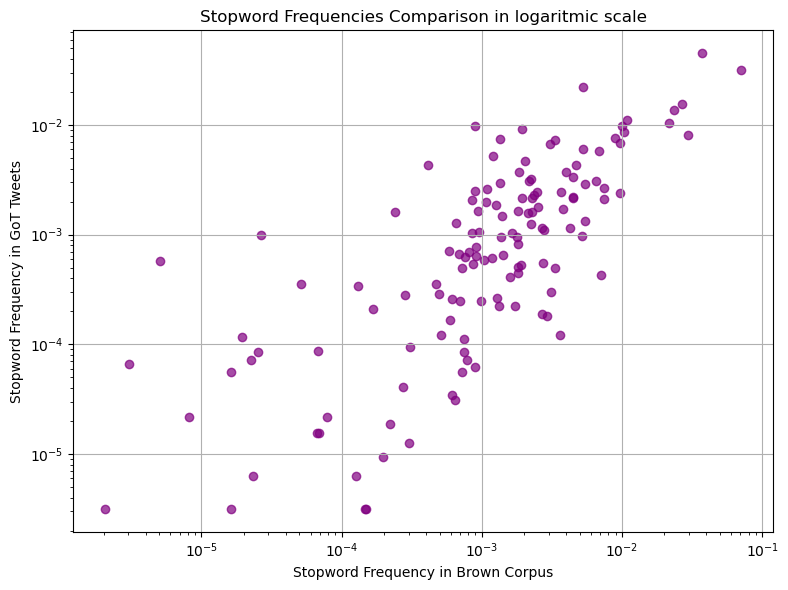

In [18]:

plt.figure(figsize=(8, 6))
plt.scatter(brown_values, tweet_values, color='purple', alpha=0.7)
plt.xlabel("Stopword Frequency in Brown Corpus")
plt.ylabel("Stopword Frequency in GoT Tweets")
plt.title("Stopword Frequencies Comparison in logaritmic scale")
plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()




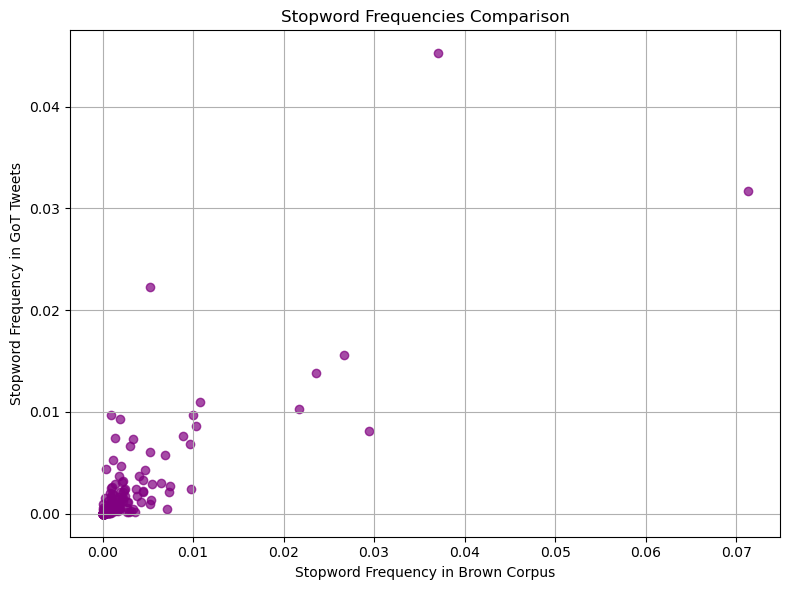

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(brown_values, tweet_values, color='purple', alpha=0.7)
plt.xlabel("Stopword Frequency in Brown Corpus")
plt.ylabel("Stopword Frequency in GoT Tweets")
plt.title("Stopword Frequencies Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Step 7: Correlation
correlation, _ = pearsonr(brown_values, tweet_values)
print(f"Pearson Correlation: {correlation:.4f}")

Pearson Correlation: 0.8142


## Exercise 4

A really common tool to visualize texts is a wordcloud. Find a suitable library and create a meaningful wordcloud of the GoT tweets (e.g. leave out punctuation, stopwords etc.)

In [21]:
#pip install wordcloud 


In [24]:
from wordcloud import WordCloud

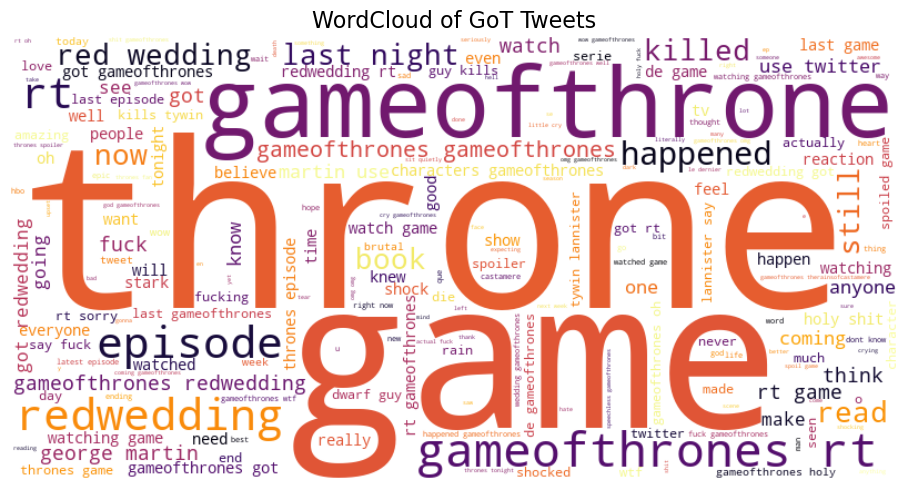

In [25]:
wordcloud_input = ' '.join(all_real_words)

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(wordcloud_input)

# Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of GoT Tweets", fontsize=16)
plt.tight_layout()
plt.show()


## Exercise 5

Define a time window in which all tweets count as one document. Create the term-document matrix of the tweets for this time segmentation. Apply stemming and stopword filtering.

In [27]:
list(df)

['id',
 'created_at',
 'created_at_shift',
 'from_user',
 'from_user_id',
 'from_user_id_str',
 'from_user_name',
 'id_str',
 'in_reply_to_status_id',
 'in_reply_to_status_id_str',
 'iso_language_code',
 'latitude',
 'longitude',
 'metadata',
 'place',
 'profile_image_url',
 'profile_image_url_https',
 'query',
 'source',
 'text',
 'to_user',
 'to_user_id',
 'to_user_id_str',
 'to_user_name',
 'type']

In [28]:

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from datetime import datetime

stemmer = PorterStemmer()

# Example tweet dataset with timestamps


# Convert to DataFrame
df["created_at"] = pd.to_datetime(df["created_at"])
df["date"] = df["created_at"].dt.date  # group by day

# Preprocessing function
def preprocess(text):
    tokens = []
    for word in text.split():
        if re.match(r'http[s]?://', word): continue
        if word.startswith('@'): continue
        if re.search(r'[\U00010000-\U0010ffff]', word): continue
        if any(char.isdigit() for char in word): continue

        word = word.strip(string.punctuation)
        if word.startswith('#'):
            word = word[1:]

        word = word.lower()
        if word.isalpha() and word not in stop_words:
            stemmed = stemmer.stem(word)
            tokens.append(stemmed)

    return ' '.join(tokens)

# Apply preprocessing
df["cleaned"] = df["text"].apply(preprocess)

# Group tweets by day (each day is a document)
grouped = df.groupby("date")["cleaned"].apply(lambda x: ' '.join(x)).reset_index()

# Create term-document matrix
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(grouped["cleaned"])

# Put in DataFrame for readability
td_matrix = pd.DataFrame(X.toarray(), index=grouped["date"], columns=vectorizer.get_feature_names_out())

print("Term-Document Matrix:")
print(td_matrix)


Term-Document Matrix:
            aaa  aaaaaaaaaaaaaa  aaaaaaaaaaaaaaaaaaaaaaaaaaah  \
date                                                            
2013-06-03    4               1                             1   

            aaaaaaaaaaaaaaaaaaaah  aaaaaaaaaaah  aaaaaaaah  aaaaaaaand  \
date                                                                     
2013-06-03                      1             1          1           1   

            aaaaaaah  aaaaaaarrrrrrgggghhhh  aaaaaaauuuuugghh  ...  zoraki  \
date                                                           ...           
2013-06-03         1                      2                 1  ...       1   

            zorra  zou  zu  zustand  zwaar  zwart  zwrot  zy  zynga  
date                                                                 
2013-06-03      1    2   6        1      1      1      1   1      2  

[1 rows x 13476 columns]


## Exercise 6

Apply a TF-IDF weighting scheme for the term-document matrix by hand (e.g. do not use a built-in vectorizer, but normalize by text length with a summation etc. `numpy` or `pandas` is strongly suggested). Then, choose a topic detection method such as LSI or LDA, and run it on your matrix. Try to interpret your results! Are your topics meaningful? Which topics are the most representative of your document?

## Exercise 7

Write an own name parser for the tweets, and consider all names that you find in the dataset as a node of a graph. Add 1 to the weight of an edge if two names occur in the same tweet. With the help of networkx, draw the weighted network of names from the text. Try to find a simple clustering algorithm in networkx, cluster the names in the dataset. Print or visualize your results!

## Exercise 8

This episode caused severe disappointments in many viewers, because of the sudden death of too many of the favourite characters. Search for some sentiment analysis method, and create a timeline of sentiments based on the tweet texts. Do the sentiments on Twitter reflect the time of the worst scene?

In [29]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [30]:
download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /v/x38j5q/nltk_data...


True

/tmp/ipykernel_3463/398966096.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timeline = df["sentiment"].resample("5T").mean()  # '5T' = 5-minute intervals


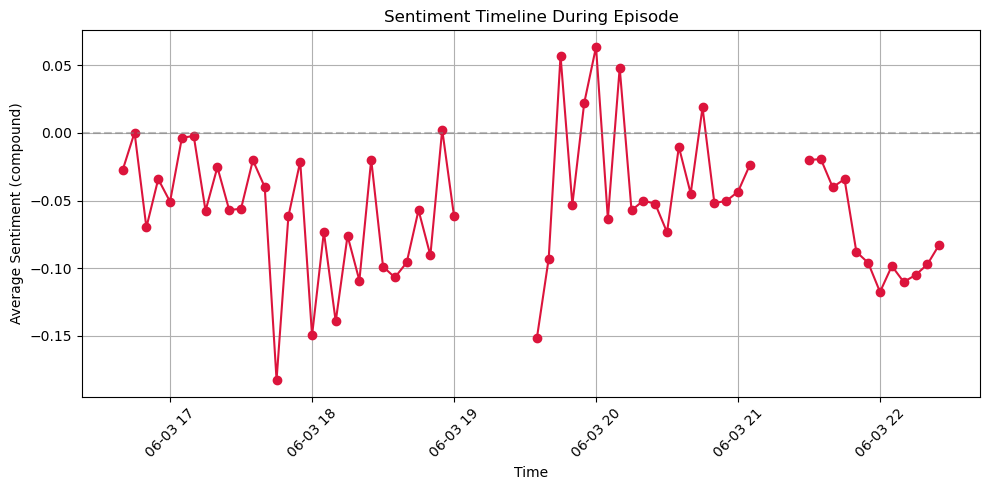

In [31]:
sia = SentimentIntensityAnalyzer()
# Convert to DataFrame
df["created_at"] = pd.to_datetime(df["created_at"])

# Optional: Clean text (basic)
def clean_text(text):
    text = re.sub(r"http\S+|@\S+|#\S+", "", text)  # Remove URLs, mentions, hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.lower()

df["cleaned_text"] = df["text"].apply(clean_text)

# Compute sentiment scores
df["sentiment"] = df["cleaned_text"].apply(lambda x: sia.polarity_scores(x)["compound"])

# Resample sentiment over time (e.g., 5-minute bins)
df.set_index("created_at", inplace=True)
timeline = df["sentiment"].resample("5T").mean()  # '5T' = 5-minute intervals

# Plot sentiment timeline
plt.figure(figsize=(10, 5))
plt.plot(timeline.index, timeline.values, marker='o', color='crimson')
plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.title("Sentiment Timeline During Episode")
plt.xlabel("Time")
plt.ylabel("Average Sentiment (compound)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
